# DIS22 - Forschungsfrage

**Wie hat sich der Grad der Informationsueberschneidung zwischen Tabellen und Fliestext in bioRxiv-Preprints ueber die Jahre veraendert?**

Pro Tabelle: Overlap-Score = Anteil der Dezimalzahlen aus der Tabelle, die auch in den Textreferenzen vorkommen.
- Score = 0 → Tabelle komplett eigenstaendig
- Score = 1 → alle Zahlen auch im Fliesstext

In [1]:
import json
import re
import pathlib
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [2]:
# Pfad-Erkennung: funktioniert in VS Code, Jupyter und nbconvert
notebook_path = globals().get('__vsc_ipynb_file__')  # VS Code

if notebook_path:
    NOTEBOOK_DIR = pathlib.Path(notebook_path).resolve().parent
else:
    # Fallback: Verzeichnis, aus dem Jupyter/nbconvert gestartet wurde
    NOTEBOOK_DIR = pathlib.Path.cwd()

OUTPUT_DIR = NOTEBOOK_DIR / 'output'

# Falls output/ nicht gefunden: cwd als zweiten Versuch nutzen
if not OUTPUT_DIR.exists():
    OUTPUT_DIR = pathlib.Path.cwd() / 'output'

if not OUTPUT_DIR.exists():
    raise FileNotFoundError(
        f'output-Ordner nicht gefunden.\n'
        f'Gesucht in: {NOTEBOOK_DIR / "output"}\n'
        f'und in:     {pathlib.Path.cwd() / "output"}\n'
        'Bitte das Notebook aus dem Ordner starten, der output/ enthaelt.'
    )

json_files = sorted(OUTPUT_DIR.glob('*.json'))
print(f'Notebook-Verzeichnis : {NOTEBOOK_DIR}')
print(f'output-Verzeichnis   : {OUTPUT_DIR}')
print(f'Gefundene JSON-Dateien: {len(json_files)}')

if not json_files:
    raise FileNotFoundError('Keine JSON-Dateien in output/ gefunden!')

Notebook-Verzeichnis : /sessions/festive-determined-pasteur/mnt/DIS22
output-Verzeichnis   : /sessions/festive-determined-pasteur/mnt/DIS22/output
Gefundene JSON-Dateien: 499


In [3]:
def get_numbers(text):
    # Nur Dezimalzahlen (z.B. 3.14 oder 0,87) – reduziert Rauschen
    nums = re.findall(r'\d+[.,]\d+', text or '')
    return set(nums)

rows = []

for fpath in tqdm(json_files, desc='Dokumente verarbeiten'):
    with open(fpath, encoding='utf-8') as f:
        doc = json.load(f)

    meta = doc.get('metadata') or {}
    year = meta.get('preprint_date', '')[:4]
    if not year:
        continue

    for tab in doc.get('tables', []):
        content_raw = tab.get('content')
        refs = tab.get('references') or []
        if not content_raw or not refs:
            continue
        try:
            content = json.loads(content_raw) if isinstance(content_raw, str) else content_raw
            cells = ' '.join(str(v) for row in content.get('data', []) for v in row)
        except Exception:
            continue
        table_nums = get_numbers(cells)
        ref_nums   = get_numbers(' '.join(refs))
        if not table_nums:
            continue
        overlap = len(table_nums & ref_nums) / len(table_nums)
        rows.append({'year': year, 'overlap': overlap})

df = pd.DataFrame(rows)
print(f'Auswertbare Tabellen: {len(df)}')

if df.empty:
    raise ValueError('Keine Zeilen im DataFrame – pruefen ob output/ die richtigen Dateien enthaelt.')

print(df.groupby('year').size().rename('Tabellen pro Jahr'))

Dokumente verarbeiten:   0%|          | 0/499 [00:00<?, ?it/s]

Auswertbare Tabellen: 289
year
2022      6
2023      4
2024     49
2025    230
Name: Tabellen pro Jahr, dtype: int64


In [4]:
yearly = df.groupby('year')['overlap'].mean()
print(yearly.rename('Overlap-Score (Durchschnitt)'))

year
2022    0.000000
2023    0.011111
2024    0.016157
2025    0.028722
Name: Overlap-Score (Durchschnitt), dtype: float64


In [5]:
x = yearly.index.astype(int).values
y = yearly.values

slope, intercept, r, p, se = stats.linregress(x, y)
print(f'Trend:  {slope:+.4f} pro Jahr')
print(f'p-Wert: {p:.4f}')
print(f'R2:     {r**2:.3f}')

Trend:  +0.0091 pro Jahr
p-Wert: 0.0115
R2:     0.977


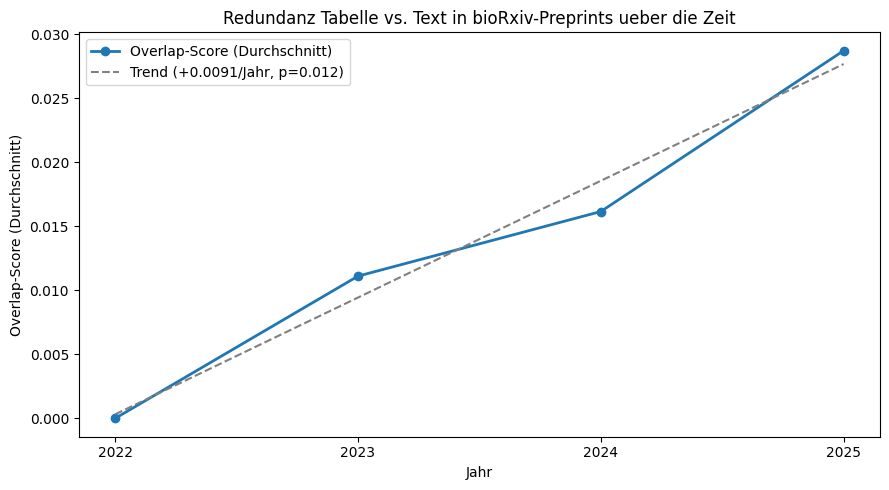

Plot gespeichert als overlap_trend.png


In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(yearly.index, yearly.values, marker='o', linewidth=2,
        label='Overlap-Score (Durchschnitt)')

trend_y = slope * x + intercept
ax.plot(yearly.index, trend_y, linestyle='--', color='grey',
        label=f'Trend ({slope:+.4f}/Jahr, p={p:.3f})')

ax.set_xlabel('Jahr')
ax.set_ylabel('Overlap-Score (Durchschnitt)')
ax.set_title('Redundanz Tabelle vs. Text in bioRxiv-Preprints ueber die Zeit')
ax.legend()
plt.tight_layout()
plt.savefig('overlap_trend.png', dpi=150)
plt.show()
print('Plot gespeichert als overlap_trend.png')